# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import soundfile as sf
#import warnings

from IPython.display import display, Audio
#from IPython.display import HTML
#from ipywidgets import Output, GridspecLayout

# Chapter 11: Infinite impulse response filters

## 11.1 Feedback filters

### 11.1.1. Example: exponential moving average

> As an introduction to feedback filters, let’s imagine the following process for computing a moving average of a signal $x[n]$, resulting in output signal $y[n]$.


\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#e41a1c}\frac{1}{2}} \cdot {\color{#377eb8}x[n]} + {\color{#4daf4a}\frac{1}{2}} \cdot {\color{#984ea3}y[n-1]} & \text{(11.1)}  \\
\end{flalign}

#### Key points

* This is a **feedback** process since ${\color{#984ea3}y[n]}$ depend on both **feed-forward** process ${\color{#377eb8}x[n]}$ as well as **previous output** ${\color{#984ea3}y[n-1]}$.
* Convention is that ${\color{#984ea3}y[-1] = 0}$, so initial output value is given by ${\color{#984ea3}y[0]} = {\color{#e41a1c}\frac{1}{2}} \cdot {\color{#377eb8}x[0]}$.
* As with convolutional filters, we can analyze the behavior of (11.1) by sending an impulse signal ${\color{#377eb8}x = [1, 0, 0, \ldots]}$ into the system and seeing how it responds.

\begin{flalign}
\qquad {\color{#377eb8}x[0] = 1} \quad \Rightarrow \quad &{\color{#984ea3}y[0] = \frac{1}{2}} & \\
\qquad {\color{#377eb8}x[1] = 0} \quad \Rightarrow \quad &{\color{#984ea3}y[1] = \frac{1}{2} \cdot y[0] = \frac{1}{4}} & \\
\qquad {\color{#377eb8}x[2] = 0} \quad \Rightarrow \quad &{\color{#984ea3}y[2] = \frac{1}{2} \cdot y[1] = \frac{1}{8}} & \\
\qquad {\color{#377eb8}x[3] = 0} \quad \Rightarrow \quad &{\color{#984ea3}y[3] = \frac{1}{2} \cdot y[2] = \frac{1}{16}} & \\
\qquad     & \ldots & \\
\qquad     &{\color{#984ea3}y[n] = 2^{-(n+1)}} & \\
\end{flalign}

* _... and now we know where "exponential" comes from!_
* _Note that ${\color{#984ea3}y}$ will continue to be halved, never actually reaching zero but always approaching it, and that's where "infinite" comes from..._

### 11.1.2. IIR Filters

#### Definition 11.1 (Linear IIR filter)

The general formula for a linear IIR filter is:

\begin{flalign}
\qquad {\color{#4daf4a}a[0]} \cdot {\color{#984ea3}y[n]} &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot {\color{#984ea3}y[n-k]} & \text{(11.2)}  \\
\end{flalign}

where we have:

* **feed-forward** parameters ${\color{#e41a1c}b = [b_0, b_1, b_2, \ldots b_{K-1}]}$
* **feed-back** parameters ${\color{#4daf4a}a = [a_0, a_1, a_2, \ldots a_{K-1}]}$
* in order to avoid self-dependency case ${\color{#984ea3}y[n-0] = y[n]}$, treat ${\color{#4daf4a}a[0]}$ as a special case where for all intents and purposes we assume ${\color{#4daf4a}a[0] = 1}$
* so the **feed-back** parameters are in practice assumed to be  ${\color{#4daf4a}a = [1, a_1, a_2, \ldots a_{K-1}]}$, and this why that 2nd summation is $\sum_{{\color{#4daf4a}k=1}}^{K-1}$


### 11.1.3: Special case 1: ${\color{#4daf4a}a[0] = 1}$

As long as **feed-back** parameters are such that ${\color{#4daf4a}a[0] = 1}$, we can rearrange 11.2 to yield:

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#4daf4a}\frac{1}{a[0]}} \cdot \left( \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot {\color{#984ea3}y[n-k]} \right) & \\
\qquad                       &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot {\color{#984ea3}y[n-k]} & \\
\end{flalign}

Looking back at 11.1 and the example of the exponential moving average, we can see:
* **feed-forward** parameters ${\color{#e41a1c}b = [\frac{1}{2}]}$
* **feed-back** parameters ${\color{#4daf4a}a = [1, -\frac{1}{2}]}$

### 11.1.4: Special case 2: ${\color{#4daf4a}a[k>0] = 0}$

In the case where **feed-back** parameters are such that ${\color{#4daf4a}a[0] = 1}$ and ${\color{#4daf4a}a[k>0] = 0}$, 11.2 reduces to _standard convolution_:

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]}  & \\
\end{flalign}

* this means that FIR filters are a _special case of IIR!_

### 11.1.5. Causal filters

* The IIR filters we will study define ${\color{#984ea3}y[n]}$ in terms of inputs ${\color{#377eb8}x[n]}$ and with previous outputs up to and including ${\color{#984ea3}y[n-1]}$.
* Also note that for IIR, ${\color{#984ea3}y[n]}$ does **not** depend on _future values_ like ${\color{#377eb8}x[n+1]}$ or ${\color{#984ea3}y[n+1]}$.
* Systems with this property are **causal systems**.

### 11.1.6. Why are feedbacks subtracted instead of added?

* ... wait until next chapter, when we will learn about z-Transforms.

### 11.1.7. Summary

* Feedback systems _can have an infinite impulse response_, even when the input is finite in length.
* We can always assume the first feedback coefficient ${\color{#4daf4a}a[0] = 1}$.
* IIR filters generalize FIR filters.
* The feed-back terms are subtracted, not added, to produce each output ${\color{#984ea3}y[n]}$.
* In general, **feed-forward** parameters ${\color{#e41a1c}b}$ and **feed-back** parameters ${\color{#4daf4a}a}$ need not be the same length, but we can always pad the shorter of the two with zeros to make them match.

## 11.2 Using IIR filters

### 11.2.1. IIR filters in Python

[`scipy.signal.lfilter`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html#lfilter) is a general interface for creating _linear filters_. It filters a sequence `x` using a digital filter.

At a minimum (or at least, in the examples here) the following parameters are used:
* `b`: **_array_like_**; The _numerator_ coefficient vector in a 1-D sequence.
* `a`: **_array_like_**; The _denominator_ coefficient vector in a 1-D sequence.
* `x`: **_array_like_**; An N-dimensional input array.

`lfilter` returns:
* `y`: **_array_**; The output of the digital filter.

The key point is how we obtain `b` and `a`.

In [2]:
# Compute the first few samples of the impulse response
# of an exponential moving average

x = np.array([1, 0, 0, 0, 0, 0, 0])
y = sp.signal.lfilter(
    [1/2], 
    [1, -1/2], 
    x
)

print(y)

[0.5       0.25      0.125     0.0625    0.03125   0.015625  0.0078125]


### 11.2.2. Example: Butterworth filters

In [3]:
fs = 44100  # Sampling rate
fc = 500  # Cutoff frequency

# Build the low-pass filter
b, a = sp.signal.butter(10, fc, fs=fs)

# Print the coefficients
print('Feed-forward: ', b)
print('Feed-back:    ', a)

Feed-forward:  [2.62867578e-15 2.62867578e-14 1.18290410e-13 3.15441093e-13
 5.52021913e-13 6.62426296e-13 5.52021913e-13 3.15441093e-13
 1.18290410e-13 2.62867578e-14 2.62867578e-15]
Feed-back:     [   1.           -9.54462136   41.00487909 -104.41737082  174.53480697
 -200.09486144  159.34094444  -87.02835847   31.2004603    -6.6300023
    0.6341236 ]


In [4]:
# Create the delayed impulse signal
x = np.zeros(1000)
x[249] = 1

# Apply the Butterworth filter from above
y = sp.signal.lfilter(b, a, x)

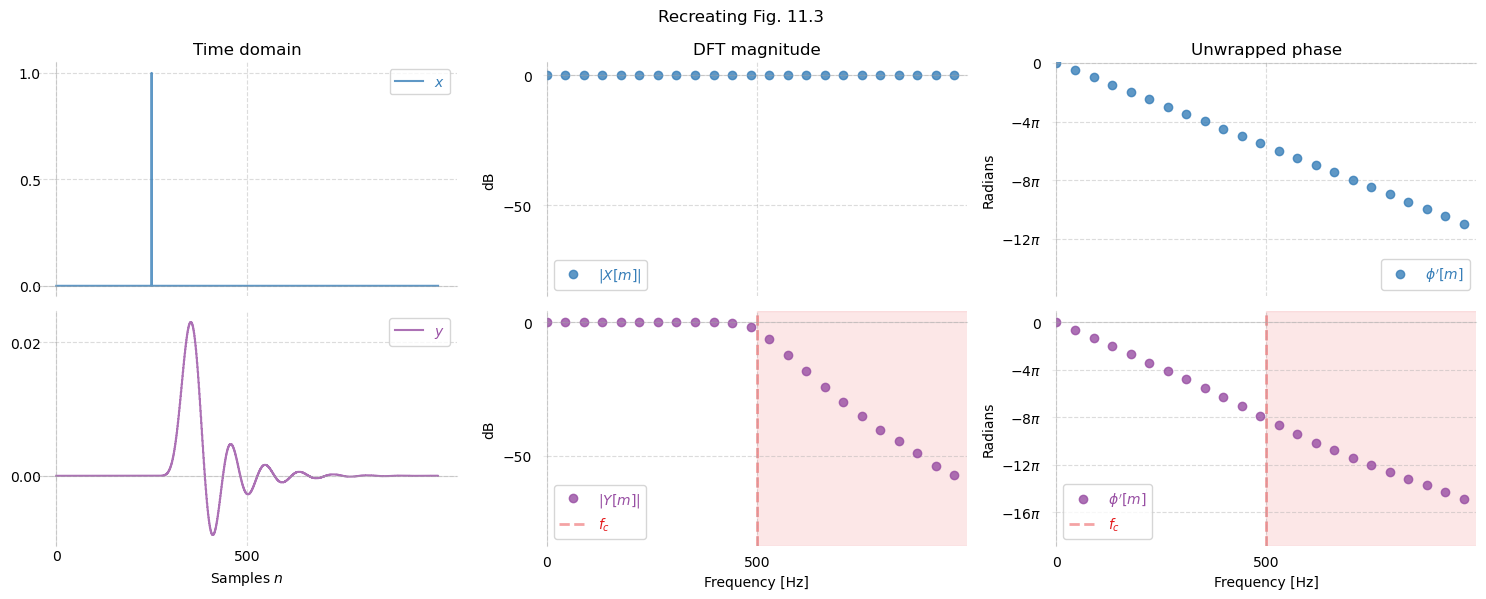

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=3, sharex='col', figsize=(15, 6))

X = np.fft.rfft(x)
Y = np.fft.rfft(y)

freqs = np.fft.rfftfreq(len(x), 1/fs)

# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 1: time domain
axes[0, 0].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[0, 0].spines['right'].set_color('none')
axes[0, 0].spines['top'].set_color('none')
axes[0, 0].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 0].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 0].set_yticks([0., 0.5, 1.])
axes[0, 0].set_xticks([0, 500])
axes[0, 0].tick_params(axis='both', which=u'both', length=3, pad=8, color='#A9A9A940')

axes[0, 0].step(np.arange(len(x)), x, where='post', label='$x$', alpha=0.8, color='#377eb8')
axes[0, 0].label_outer()
axes[0, 0].legend(loc='upper right', labelcolor='linecolor')

# BOTTOM row: y
#   column 1: time domain
axes[1, 0].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[1, 0].spines['right'].set_color('none')
axes[1, 0].spines['top'].set_color('none')
axes[1, 0].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 0].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 0].set_yticks([0., 0.02])
axes[1, 0].set_xticks([0, 500])
axes[1, 0].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1, 0].tick_params(axis='x', which=u'both', length=3, pad=50, color='#A9A9A940')

axes[1, 0].step(np.arange(len(y)), y, where='post', label='$y$', alpha=0.8, color='#984ea3')
axes[1, 0].label_outer()
axes[1, 0].set(xlabel='Samples $n$')
axes[1, 0].legend(loc='upper right', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 2: DFT magnitude
axes[0, 1].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
# Eliminate upper and right axes
axes[0, 1].spines['right'].set_color('none')
axes[0, 1].spines['top'].set_color('none')
axes[0, 1].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 1].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 1].set_yticks([0, -50])
axes[0, 1].set_xticks([0, 500])
axes[0, 1].tick_params(axis='both', which=u'both', length=3, pad=8, color='#A9A9A940')

axes[0, 1].step(freqs, 20 * np.log10(np.abs(X) + 1e-4), linestyle='', marker='o', label='$|X[m]|$', alpha=0.8, color='#377eb8')
axes[0, 1].set(ylim=[-85, 5])
axes[0, 1].set(ylabel='dB')

axes[0, 1].legend(loc='lower left', labelcolor='linecolor')


# BOTTOM row: y
#   column 2: DFT magnitude
axes[1, 1].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[1, 1].spines['right'].set_color('none')
axes[1, 1].spines['top'].set_color('none')
axes[1, 1].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 1].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 1].set_yticks([0, -50])
axes[1, 1].set_xticks([0, 500])
axes[1, 1].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1, 1].tick_params(axis='x', which=u'both', length=3, pad=165, color='#A9A9A940')

axes[1, 1].step(freqs, 20 * np.log10(np.abs(Y) + 1e-4), linestyle='', marker='o', label='$|Y[m]|$', alpha=0.8, color='#984ea3')
axes[1, 1].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[1, 1].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

axes[1, 1].set(xlabel='Frequency [Hz]')
axes[1, 1].set(ylabel='dB')
axes[1, 1].legend(loc='lower left', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 3: unwrapped phase
axes[0, 2].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[0, 2].spines['right'].set_color('none')
axes[0, 2].spines['top'].set_color('none')
axes[0, 2].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 2].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 2].set_yticks(np.linspace(0, -16*np.pi, 5), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$',  r'$-16\pi$'])
axes[0, 2].set_xticks([0, 500])
axes[0, 2].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[0, 2].tick_params(axis='x', which=u'both', length=3, color='#A9A9A940')

axes[0, 2].plot(freqs, np.unwrap(np.angle(X)), linestyle='', marker='o', label=r"$\phi'[m]$", alpha=0.8, color='#377eb8')
axes[0, 2].set(ylabel="Radians")
axes[0, 2].legend(loc='lower right', labelcolor='linecolor')

# BOTTOM row: y
#   column 3: unwrapped phase
axes[1, 2].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
axes[1, 2].spines['right'].set_color('none')
axes[1, 2].spines['top'].set_color('none')
axes[1, 2].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 2].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 2].set_yticks(np.linspace(0, -16*np.pi, 5), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$',  r'$-16\pi$'])
axes[1, 2].set_xticks([0, 500])
axes[1, 2].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1, 2].tick_params(axis='x', which=u'both', length=3, pad=165, color='#A9A9A940')

# Eliminate upper and right axes
axes[1, 2].plot(freqs, np.unwrap(np.angle(Y)), linestyle='', marker='o', label=r"$\phi'[m]$", alpha=0.8, color='#984ea3')
axes[1, 2].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[1, 2].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)
axes[1, 2].legend(loc='lower left', labelcolor='linecolor')
axes[1, 2].set(xlabel='Frequency [Hz]')
axes[1, 2].set(ylabel="Radians")
axes[1, 2].set(xlim=[0, 1000])


axes[1, 1].set(xlim=[0, 1000])
axes[0, 0].set(title='Time domain')
axes[0, 1].set(title='DFT magnitude')
axes[0, 2].set(title='Unwrapped phase')
axes[0, 2].set(ylim=[-50, 0.1])

#glue('butter', fig, display=False)
fig.tight_layout()
plt.suptitle('Recreating Fig. 11.3', y=1.03)
plt.show()

### 11.2.3. Selecting the order

For the IIR filters we're covering, the scipy way of doing things is:

1. Pick an IIR filter strategy.
2. Find the helper function (if any) for that IIR filter strategy for determining the smallest order $K$ given the specified constraints for your filter.
3. Construct the IIR filter using the order determined in 2 above, passing in any necessary arguments like cut-off frequency $f_c$ and sampling frequency $f_s$.

For the Butterworth filter:
* [`scipy.signal.buttord`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.buttord.html#buttord) is used to determine order $K$
* [`scipy.signal.butter`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html#butter) is used to construct the filter

In [6]:
fc = 500  # Cutoff at 500 Hz
fstop = 1000  # End the transition band at 1000 Hz
passband_ripple = 3  # 3dB ripple
stopband_atten = 60  # 60 dB attenuation of the stop-band

# Get the smallest order for the filter
order, _ = sp.signal.buttord(fc, fstop, passband_ripple, stopband_atten, fs=fs)

# Now construct the filter
b, a = sp.signal.butter(order, fc, fs=fs)

# Lastly, apply the Butterworth filter to your signal x
#y = sp.signal.lfilter(b, a, x)

### 11.2.4. Compensating for phase distortion

Please see [`scipy.signal.filtfilt`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html#filtfilt)

In [7]:
# Build the low-pass filter for double-filtering
# This means we'll cut the pass-band ripple and stop-band attenuation both in half
# We only need the first output from buttord
order2, _ = sp.signal.buttord(fc, fstop, passband_ripple/2, stopband_atten/2, fs=fs)

b2, a2 = sp.signal.butter(order2, fc, fs=fs)

# Apply the double filter
y2 = sp.signal.filtfilt(b2, a2, x)

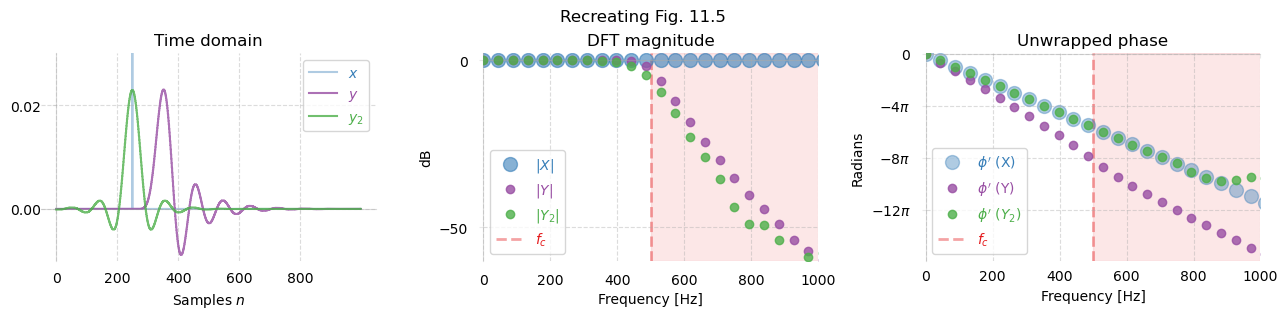

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 3))

X = np.fft.rfft(x)
Y = np.fft.rfft(y)
Y2 = np.fft.rfft(y2)

freqs = np.fft.rfftfreq(len(x), 1/fs)

# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 1: time domain
axes[0].set(title='Time domain')
axes[0].set(xlabel='Samples $n$')
axes[0].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[0].spines['right'].set_color('none')
axes[0].spines['top'].set_color('none')
axes[0].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0].set_yticks([0., 0.02])
axes[0].set_ylim([-0.01, 0.03])
axes[0].set_xticks([0, 200, 400, 600, 800])
axes[0].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[0].tick_params(axis='x', which=u'both', length=3, pad=42, color='#A9A9A940')

axes[0].step(np.arange(len(x)), x, where='post', label='$x$', alpha=0.4, color='#377eb8', zorder=1)
axes[0].step(np.arange(len(y)), y, where='post', label='$y$', alpha=0.8, color='#984ea3', zorder=2)
axes[0].step(np.arange(len(y2)), y2, where='post', label=r'$y_2$', alpha=0.8, color='#4daf4a', zorder=20)

axes[0].label_outer()
axes[0].legend(loc='upper right', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 2: DFT magnitude
axes[1].set(title='DFT magnitude')
axes[1].set(xlabel='Frequency [Hz]')
axes[1].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[1].spines['right'].set_color('none')
axes[1].spines['top'].set_color('none')
axes[1].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1].set_yticks([0, -50])
axes[1].set_xticks([0, 200, 400, 600, 800, 1000])
axes[1].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1].tick_params(axis='x', which=u'both', length=3, pad=150, color='#A9A9A940')

axes[1].step(freqs, 20 * np.log10(np.abs(X) + 1e-4), linestyle='', marker='o', markersize=10, zorder=1, label='$|X|$', alpha=0.6, color='#377eb8')
axes[1].step(freqs, 20 * np.log10(np.abs(Y) + 1e-4), linestyle='', marker='o', zorder=2, label='$|Y|$', alpha=0.8, color='#984ea3')
axes[1].step(freqs, 20 * np.log10(np.abs(Y2) + 1e-4), linestyle='', marker='o', zorder=20, label=r'$|Y_2|$', alpha=0.8, color='#4daf4a')
axes[1].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[1].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

axes[1].set(ylim=[-60, 2.], xlim=[-0.5, 1000])
axes[1].set(ylabel='dB')

axes[1].legend(loc='lower left', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 3: unwrapped phase
axes[2].set(title='Unwrapped phase')
axes[2].set(xlabel='Frequency [Hz]')
axes[2].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[2].spines['right'].set_color('none')
axes[2].spines['top'].set_color('none')
axes[2].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[2].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[2].set_yticks(np.linspace(0, -16*np.pi, 5), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$',  r'$-16\pi$'])
axes[2].set_xticks([0, 200, 400, 600, 800, 1000])
axes[2].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[2].tick_params(axis='x', which=u'both', length=3, pad=152, color='#A9A9A940')

axes[2].plot(freqs, np.unwrap(np.angle(X)), linestyle='', marker='o', markersize=10, zorder=1, label=r"$\phi' \text{ (X)}$", alpha=0.4, color='#377eb8')
axes[2].plot(freqs, np.unwrap(np.angle(Y)), linestyle='', marker='o', markersize=6, zorder=2, label=r"$\phi' \text{ (Y)}$", alpha=0.8, color='#984ea3')
axes[2].plot(freqs, np.unwrap(np.angle(Y2)), linestyle='', marker='o', markersize=6, zorder=20, label=r"$\phi' \text{ (}Y_2\text{)}$", alpha=0.8, color='#4daf4a')

axes[2].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[2].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

axes[2].set(ylim=[-60, 1.], xlim=[-0.5, 1000])
axes[2].set(ylabel="Radians")
axes[2].legend(loc='lower left', labelcolor='linecolor')

axes[2].set(ylim=[-50, 0.1])

fig.tight_layout()
plt.suptitle('Recreating Fig. 11.5', y=1.03)
plt.show()

#### Take-away points for IIR filters so far...

* The double-filtering approach effectively aligns the final output to the input, as evidenced by the time-domain representations peaking in exactly the same sample index.
* However, note that reverse-filtering introduces pre-echo: the oscillations in $y_2$ preceding the peak at $n = 249$.
* This result is similar to the FIR filter outputs in chapter 10, (c.f. [Fig. 10.8](https://brianmcfee.net/dstbook-site/content/ch10-convtheorem/FilterDesign.html#pmfir)), and is to some extent unavoidable if we’re applying low-pass filtering to signals with strong transients.
* Remember: although the outputs are similar, we got there with much less work: an order-6 IIR filter applied twice, compares well to FIR filters with order in the hundreds.

## 11.3. Common IIR filters

### 11.3.1. Chebyshev filters

#### 11.3.1.1. Type 1

* Please see [`scipy.signal.cheb1ord`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.cheb1ord.html#cheb1ord) for the helper function to determine suitable order $K$.
* Also see [`scipy.signal.cheby1`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cheby1.html#cheby1) for the helper function that constructs the filter (computes $b$ and $a$).

In [9]:
# we'll keep using the variables already defined

#ripple = 3  # we'll allow 3 dB ripple in the passband
#attenuation = 60  # we'll require 60 dB attenuation in the stop band

# Get the order and discard the second output (natural frequency)
#order, _  = scipy.signal.cheb1ord(fc, fstop, ripple, attenuation, fs=fs)
order1, _  = sp.signal.cheb1ord(fc, fstop, passband_ripple, stopband_atten, fs=fs)

# Build the filter, passing in:
# - max. allowed passband ripple
# - the cutoff frequency
b3, a3 = sp.signal.cheby1(order1, passband_ripple, fc, fs=fs)

# Apply the Type 1 Chebyshev filter
y3 = sp.signal.filtfilt(b3, a3, x)

#### 11.3.1.2. Type 2

* Please see [`scipy.signal.cheb2ord`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cheb2ord.html#cheb2ord) for the helper function to determine suitable order $K$.
* Also see [`scipy.signal.cheby2`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cheby2.html#cheby2) for the helper function that constructs the filter (computes $b$ and $a$).

In [10]:
# Get the order and discard the second output (natural frequency)
order2, _  = sp.signal.cheb2ord(fc, fstop, passband_ripple, stopband_atten, fs=fs)

# Build the filter, passing in:
# - stop-band attenuation
# - the end of the transition band region
b4, a4 = sp.signal.cheby2(order2, stopband_atten, fstop, fs=fs)

# Apply the Type 1 Chebyshev filter
y4 = sp.signal.filtfilt(b4, a4, x)

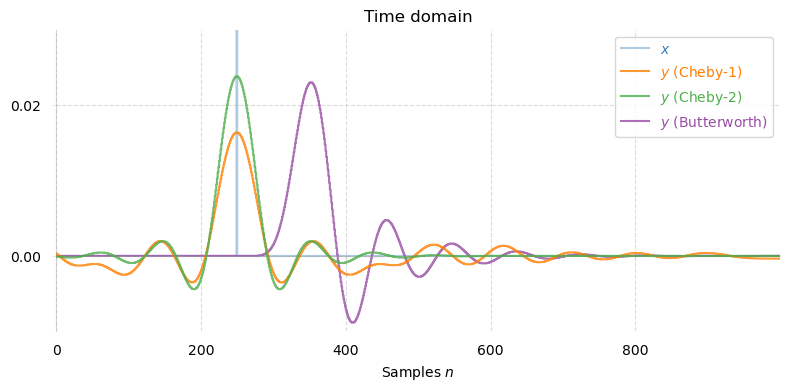

In [15]:
# --------------------------------------------------------------------
# Time domain: compare x, y (Cheby-19, y (Cheyb-2), and y (Butterworth)
#
fig, ax = plt.subplots(figsize=(8, 4))

ax.set(title = 'Time domain')
ax.set(xlabel='Samples $n$')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0., 0.02])
ax.set_ylim([-0.01, 0.03])
ax.set_xticks([0, 200, 400, 600, 800])
ax.set_xlim([-0.01, 1000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=60, color='#A9A9A940')

ax.step(np.arange(len(x)), x, where='post', label='$x$', alpha=0.4, color='#377eb8', zorder=1)
ax.step(np.arange(len(y)), y3, where='post', label='$y$ (Cheby-1)', alpha=0.8, color='#ff7f00', zorder=3)
ax.step(np.arange(len(y)), y4, where='post', label='$y$ (Cheby-2)', alpha=0.8, color='#4daf4a', zorder=4)
ax.step(np.arange(len(y)), y, where='post', label='$y$ (Butterworth)', alpha=0.8, color='#984ea3', zorder=2)

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')

plt.show()

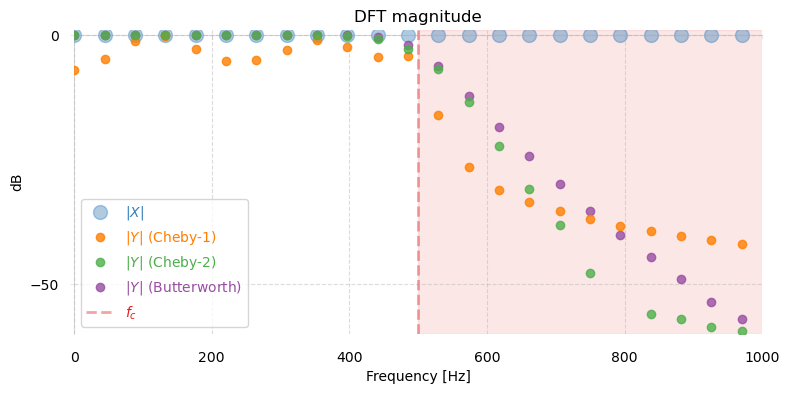

In [14]:
# --------------------------------------------------------------------
# DFT magnitude: compare X, Y (Cheby-19, Y (Cheyb-2), and Y (Butterworth)
#
Y_cheby1 = np.fft.rfft(y3)
Y_cheby2 = np.fft.rfft(y4)

fig, ax = plt.subplots(figsize=(8, 4))

ax.set(title='DFT magnitude')
ax.set(xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0, -50])
ax.set_xticks([0, 200, 400, 600, 800, 1000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=224, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(X) + 1e-4), linestyle='', marker='o', markersize=10, zorder=1, label=r'$|X|$', alpha=0.4, color='#377eb8')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby1) + 1e-4), linestyle='', marker='o', zorder=3, label='$|Y|$ (Cheby-1)', alpha=0.8, color='#ff7f00')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby2) + 1e-4), linestyle='', marker='o', zorder=4, label='$|Y|$ (Cheby-2)', alpha=0.8, color='#4daf4a')
ax.step(freqs, 20 * np.log10(np.abs(Y) + 1e-4), linestyle='', marker='o', zorder=2, label='$|Y|$ (Butterworth)', alpha=0.8, color='#984ea3')

ax.axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
ax.axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

ax.set(ylim=[-60, 1.], xlim=[-0.5, 1000])
ax.set(ylabel='dB')

fig.tight_layout()
ax.legend(loc='lower left', labelcolor='linecolor')

plt.show()

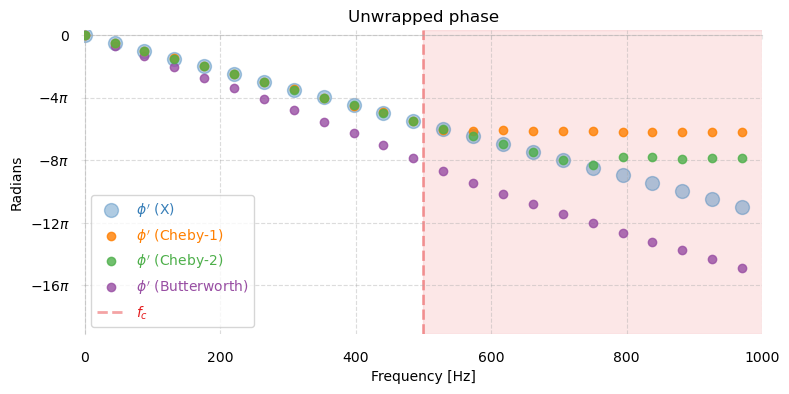

In [16]:
# --------------------------------------------------------------------
# Unwrapped phase: compare X, Y (Cheby-19, Y (Cheyb-2), and Y (Butterworth)
#
fig, ax = plt.subplots(figsize=(8, 4))

ax.set(title='Unwrapped phase')
ax.set(xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks(np.linspace(0, -16*np.pi, 5), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$',  r'$-16\pi$'])
ax.set_xticks([0, 200, 400, 600, 800, 1000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=224, color='#A9A9A940')

ax.plot(freqs, np.unwrap(np.angle(X)), linestyle='', marker='o', markersize=10, zorder=1, label=r"$\phi'$ (X)", alpha=0.4, color='#377eb8')
ax.plot(freqs, np.unwrap(np.angle(Y_cheby1)), linestyle='', marker='o', markersize=6, zorder=3, label=r"$\phi'$ (Cheby-1)", alpha=0.8, color='#ff7f00')
ax.plot(freqs, np.unwrap(np.angle(Y_cheby2)), linestyle='', marker='o', markersize=6, zorder=4, label=r"$\phi'$ (Cheby-2)", alpha=0.8, color='#4daf4a')
ax.plot(freqs, np.unwrap(np.angle(Y)), linestyle='', marker='o', markersize=6, zorder=2, label=r"$\phi'$ (Butterworth)", alpha=0.8, color='#984ea3')

ax.axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
ax.axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

ax.set(ylim=[-60, 1.], xlim=[-0.5, 1000])
ax.set(ylabel='Radians')

fig.tight_layout()
ax.legend(loc='lower left', labelcolor='linecolor')

plt.show()